# Netflix Content Library Analysis

## Exploratory Data Analysis (EDA) Using Python

### Business Problem

Netflix hosts thousands of movies and TV shows from different countries, genres, and audience categories. Understanding the composition of this content library can help identify content trends, audience preferences, and regional distribution patterns.

### Project Objectives

- Analyze Movies vs TV Shows distribution.
- Identify top content-producing countries.
- Explore the most common genres on Netflix.
- Study content addition trends over time.
- Examine movie duration and TV show season patterns.
- Understand audience targeting through content ratings.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Expected Outcome

Generate business insights that could support content acquisition strategies, audience engagement, and regional expansion decisions.

# Data Loading

The dataset is loaded into a Pandas DataFrame for analysis. This dataset contains information about Netflix titles, including content type, release year, country, genre, rating, and duration.

In [574]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [575]:
data = pd.read_csv("/content/netflix_titles.csv")

# Dataset Preview

Displaying the first five records helps us understand the structure of the dataset and verify that the data has been loaded correctly.

In [576]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Last Five Records

Viewing the last few rows helps confirm dataset completeness and provides an additional check on the overall structure.

In [577]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


# Statistical Summary

This section provides descriptive statistics for numerical columns, including count, mean, standard deviation, minimum, and maximum values.

### Purpose
- Understand data distribution.
- Identify unusual values.
- Gain initial insights into numerical features.

In [578]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Dataset Dimensions

The shape of the dataset shows:

- Number of rows (records)
- Number of columns (features)

This helps estimate the scale of analysis.

In [579]:
data.shape

(8807, 12)

# Dataset Information

This step provides:

- Column names
- Data types
- Number of non-null values

It helps identify missing values and data type conversion requirements.

In [580]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Missing Value Analysis

Missing values can impact analysis quality and model performance.

This step identifies columns with incomplete information and helps determine appropriate data-cleaning strategies.

In [581]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# Missing Value Percentage

Calculating missing value percentages provides a clearer understanding of data quality and helps prioritize cleaning efforts.

In [582]:
(data.isnull().sum()/len(data)) * 100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


# Data Cleaning

To improve data quality:

- Missing directors are replaced with "Unknown".
- Missing cast information is replaced with "Unknown".
- Missing countries are replaced with "Unknown".
- Date column is converted into datetime format for time-based analysis.

This ensures consistency across the dataset.

In [583]:
data['director'] = data['director'].fillna('Unknown')
data['cast'] = data['cast'].fillna('Unknown')
data['country'] = data['country'].fillna('Unknown')

valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'NR', 'TV-Y', 'TV-Y7',
                 'TV-Y7-FV', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA', 'UR']
data = data[data['rating'].isin(valid_ratings)].copy()

data['date_added'] = pd.to_datetime(data['date_added'], format='mixed')

# Validation of Data Cleaning

Rows with invalid rating values (e.g., duration values misplaced in the rating column) are removed to ensure accurate rating analysis.

The dataset structure is reviewed again to verify successful data cleaning and data type conversions.

In [584]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8800 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8800 non-null   object        
 1   type          8800 non-null   object        
 2   title         8800 non-null   object        
 3   director      8800 non-null   object        
 4   cast          8800 non-null   object        
 5   country       8800 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8800 non-null   int64         
 8   rating        8800 non-null   object        
 9   duration      8800 non-null   object        
 10  listed_in     8800 non-null   object        
 11  description   8800 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.8+ KB


# Feature Engineering

New features are created from the date_added column:

- year_added → Year when content was added to Netflix.
- month_added → Month when content was added.

These features enable trend analysis over time.

In [585]:
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

# Content Type Distribution

## Business Question

Does Netflix primarily focus on Movies or TV Shows?

Understanding the balance between these content types helps reveal Netflix's overall content strategy.

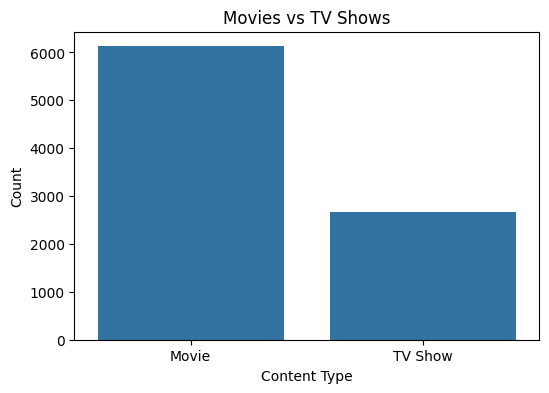

In [586]:
data['type'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(data=data, x='type')
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Insight

- Movies constitute the majority of Netflix's content library.
- TV Shows represent a smaller but significant portion.
- Netflix has historically invested more heavily in movies than serialized content.

# Content Addition Trend

## Business Question

How has Netflix expanded its content library over time?

Analyzing yearly additions helps identify growth phases and content acquisition strategies.

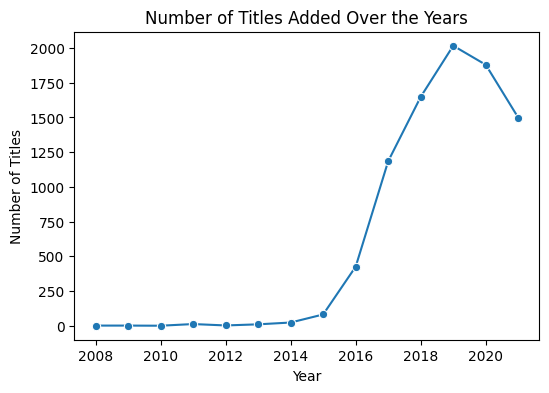

In [587]:
content_trend = data['year_added'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.lineplot(x=content_trend.index, y=content_trend.values, marker='o')
plt.title('Number of Titles Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

### Insight

- Content additions increased significantly over the years.
- Rapid growth indicates aggressive platform expansion.
- Peaks in additions may correspond to Netflix's global market expansion efforts.

# Country-Wise Content Distribution

## Business Question

Which countries contribute the most content to Netflix?

Understanding geographic distribution helps identify key production markets.

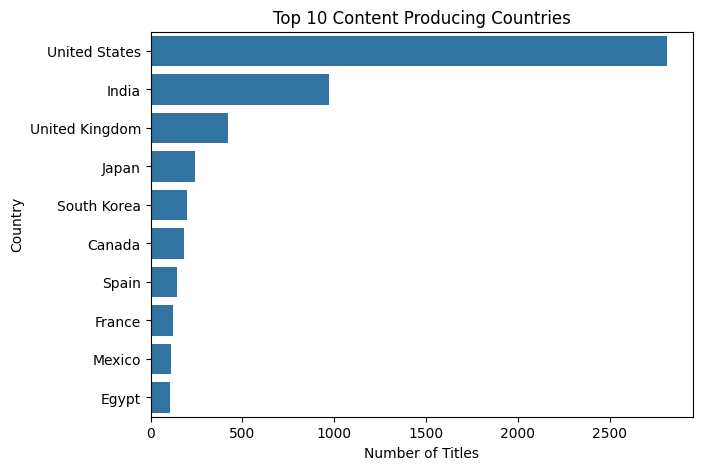

In [588]:
top_countries = data[data['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Insight

- A few countries contribute a large share of Netflix content.
- The United States dominates content production.
- Countries such as India play a major role in Netflix's international catalog.

# Genre Analysis

## Business Question

Which genres are most common on Netflix?

Genre popularity helps understand audience demand and content investment priorities.

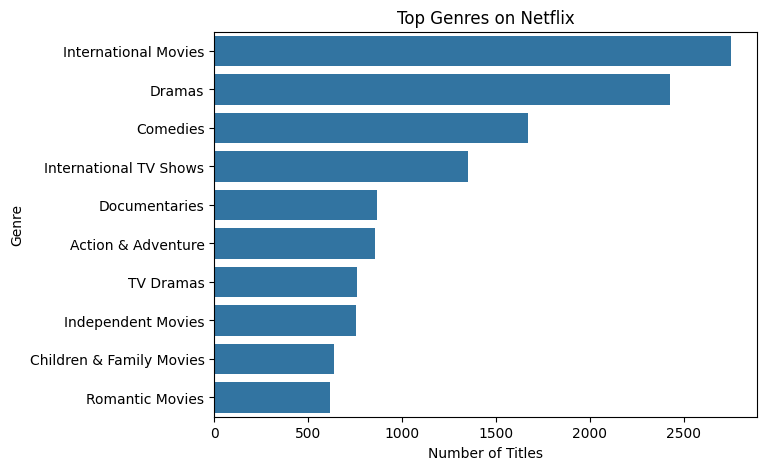

In [589]:
genres = data['listed_in'].str.split(', ')
genres = genres.explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Insight

- Drama-related genres frequently dominate the platform.
- International content categories have a strong presence.
- Netflix serves a diverse audience with a wide range of genres.

# Audience Rating Distribution

## Business Question

What audience segments does Netflix primarily target?

Content ratings provide insight into the platform's intended audience demographics.

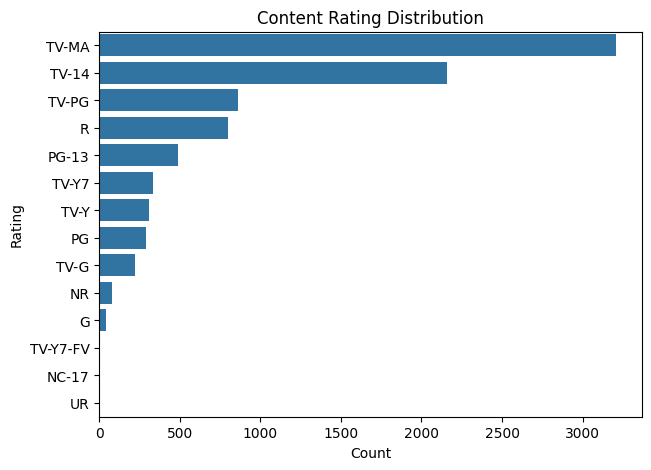

In [590]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, y='rating', order=data['rating'].value_counts().index)
plt.title("Content Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

### Insight

- Mature audience ratings appear most frequently.
- Netflix contains substantial adult-oriented content.
- Family-friendly and children's content represent smaller segments.

# Release Year Analysis

## Business Question

Does Netflix focus more on recent or older content?

Analyzing release years helps evaluate content freshness and catalog relevance.

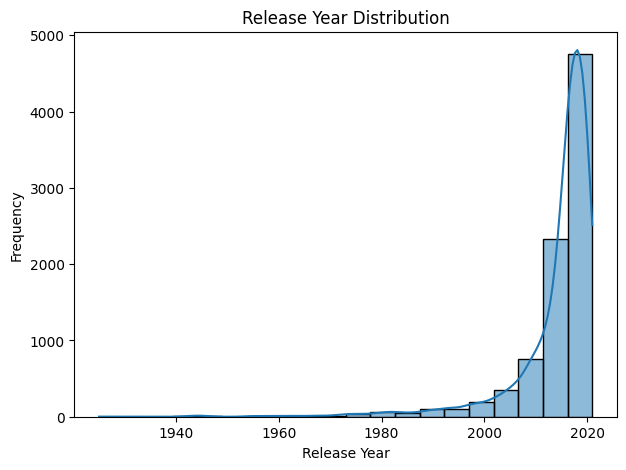

In [591]:
plt.figure(figsize=(7,5))
sns.histplot(data['release_year'], bins=20, kde=True)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

### Insight

- Most content originates from recent years.
- Netflix actively refreshes its library with newer titles.
- Older content exists but forms a smaller proportion of the catalog.

# Movie Duration Analysis

## Business Question

What is the typical movie length on Netflix?

Understanding duration patterns can reveal audience consumption preferences.

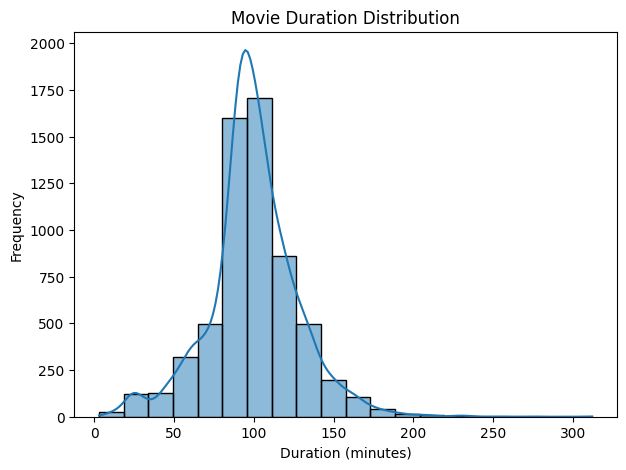

In [592]:
movies = data[data['type']=='Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(7,5))
sns.histplot(movies['duration_min'], bins=20, kde=True)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

### Insight

- Most movies fall within the standard feature-film range.
- Extremely short and extremely long movies are less common.
- Netflix appears to favor content lengths that align with mainstream viewing habits.

# TV Show Season Analysis

## Business Question

How long do Netflix TV Shows typically run?

Examining season counts helps understand content longevity and production commitments.

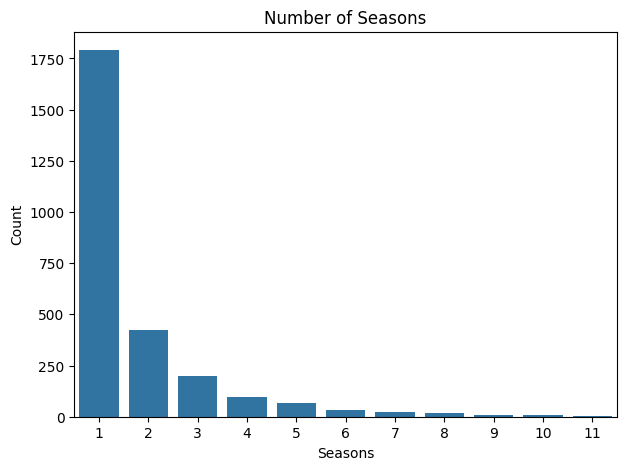

In [593]:
tv = data[data['type']=='TV Show'].copy()
tv['seasons'] = tv['duration'].str.extract(r'(\d+)')
tv['seasons'] = pd.to_numeric(tv['seasons'])

plt.figure(figsize=(7,5))
sns.countplot(data=tv, x='seasons')
plt.title("Number of Seasons")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.xlim(-0.5, 10.5)
plt.show()

### Insight

- Most TV Shows consist of only one or two seasons.
- Long-running series are comparatively rare.
- Netflix frequently introduces new shows rather than extending existing ones for many seasons.

# Comparative Trend Analysis

## Objective

Analyze the growth of Movies vs. TV Shows over time.

This comparison helps identify if Netflix's strategy has shifted towards serialized content (TV Shows) in recent years compared to feature films.
```

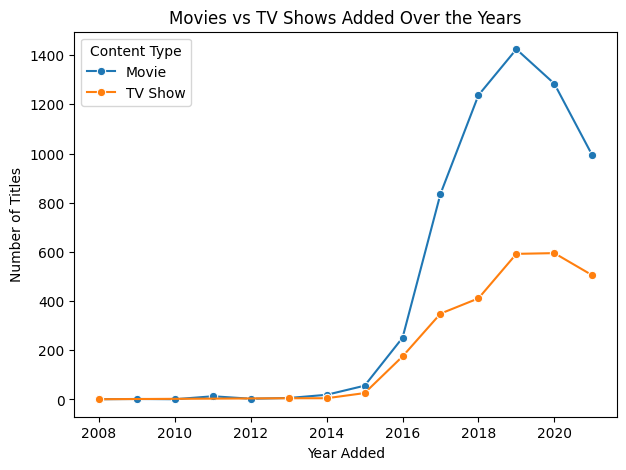

In [594]:
type_trend_flat = data.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(7,5))
sns.lineplot(data=type_trend_flat, x='year_added', y='count', hue='type', marker='o')
plt.title("Movies vs TV Shows Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

### Insight

- While Movies have always led in volume, TV Show additions saw a sharper relative increase in recent years.
- The peak for both content types occurred around 2019, followed by a slight decline, potentially influenced by production cycles or strategic shifts.
- Netflix maintains a dual-focus strategy but consistently produces more Movies annually.

# Final Conclusion

## Key Findings

1. Movies dominate Netflix's content library.
2. The United States and India are major content-producing countries.
3. Drama and International genres are highly represented.
4. Netflix primarily targets mature audiences.
5. Content additions increased significantly during growth years.
6. Most movies follow standard feature-length durations.
7. Most TV Shows have one or two seasons.

## Business Recommendations

- Continue investing in high-performing genres such as Drama and International content.
- Expand content partnerships in emerging markets.
- Maintain a balance between movies and serialized content.
- Use audience rating trends to improve content targeting strategies.

## Project Outcome

This analysis provides valuable insights into Netflix's content strategy, audience focus, and global content distribution, supporting data-driven decision-making for future content investments.